# Phase 1 - Monthly returns: drift changepoints and segmented volatility

**Corrected version.** Every change with respect to the original notebook is listed, with references, in `CORRECTIONS.md`.

The main correction concerns the modelled variable. The original models regressed the *cumulative* log-price on time with i.i.d. errors. The log-price is an integrated process, so its residuals around a trend are strongly autocorrelated (lag-1 ACF ≈ 0.5). The i.i.d. likelihood was therefore misspecified and the posterior intervals were far too narrow (spurious regression; Granger & Newbold, 1974). Here every model is written on the **monthly log-returns** $r_t$. A piecewise-linear trend in the log-price is exactly a piecewise-constant **drift** $\mu_t$ in the returns, so the model family is the same:

$$ r_t = \mu_t + \sigma_t\, \varepsilon_t $$

| Model | Drift $\mu_t$ | Volatility $\sigma_t$ | $\varepsilon_t$ |
|---|---|---|---|
| 1.1 | constant | constant | Normal |
| 1.2 | one changepoint (unknown date) | constant | Normal |
| 1.2b | yearly changepoints (Laplace shrinkage) | constant | Normal |
| 1.2d | as 1.2b | constant | Student-t |
| 1.3 | as 1.2b | one value per calendar year (hierarchical) | Normal |
| 1.3t | as 1.2b | as 1.3 | Student-t |

Models 1.3/1.3t have *segmented* (piecewise-constant) volatility. The segments are fixed calendar years, not latent states, so this is **not** a regime-switching model in the sense of Hamilton (1989).

# Import data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)
os.makedirs("plots", exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

Data are read from a **frozen snapshot** (`data/sp500_daily_2005_2025.csv`, daily ^GSPC prices from Yahoo Finance, 2005-01-03 → 2025-12-31). The original notebook downloaded fresh data at every run, which makes the results non-reproducible because Yahoo data and the yfinance API change over time.

Monthly prices are the **last daily close of each calendar month**.

In [2]:
daily = pd.read_csv("data/sp500_daily_2005_2025.csv", index_col="Date", parse_dates=True)
close_daily = daily["Close"]            # 1-D Series (not a DataFrame)

close_monthly = close_daily.resample("ME").last()
returns_monthly_all = np.log(close_monthly).diff().dropna()

# Sample split (same as the original project): estimation 2007-2022, test 2023-2025
train_start, train_end = "2007-02-01", "2022-12-31"
test_start, test_end = "2023-01-01", "2025-12-31"

returns_train = returns_monthly_all.loc[train_start:train_end]
returns_test = returns_monthly_all.loc[test_start:test_end]

r = returns_train.values
dates = returns_train.index
n = len(r)
assert r.ndim == 1

print(f"Train: {n} months ({dates[0].date()} -> {dates[-1].date()})")
print(f"Test:  {len(returns_test)} months ({returns_test.index[0].date()} -> {returns_test.index[-1].date()})")

Train: 191 months (2007-02-28 -> 2022-12-31)
Test:  36 months (2023-01-31 -> 2025-12-31)


## Data exploration

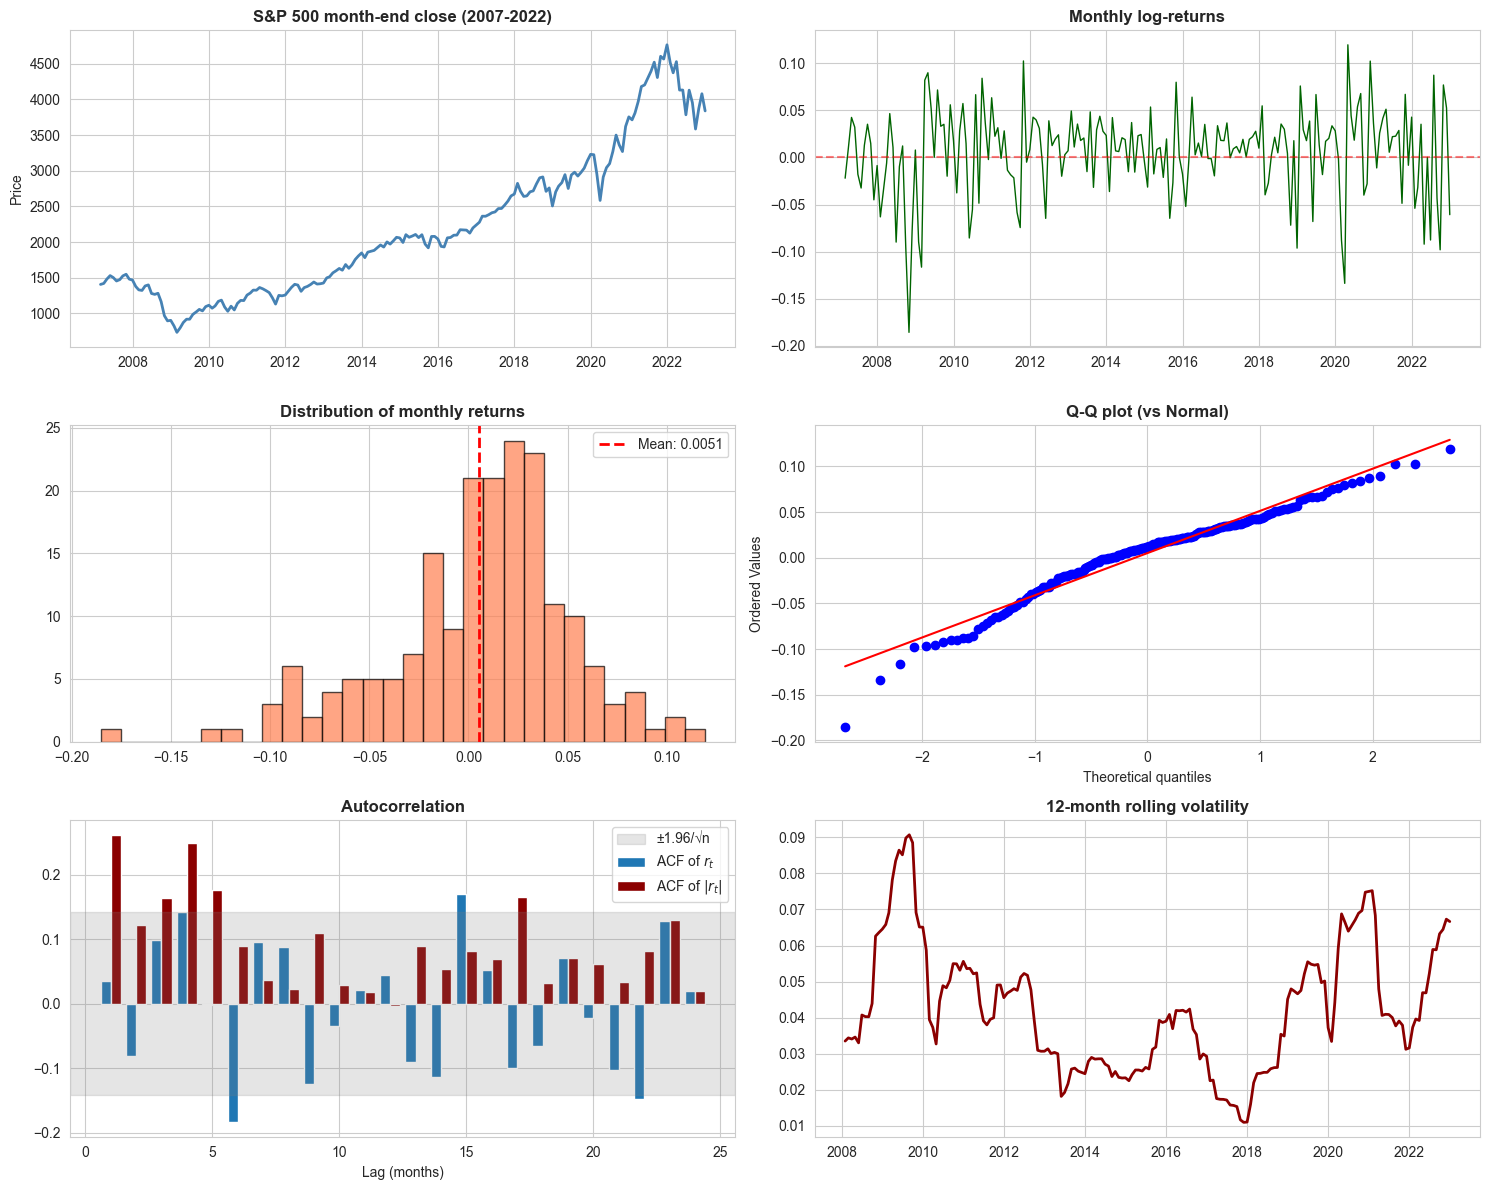

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 1. Price evolution (training window only)
axes[0, 0].plot(close_monthly.loc[train_start:train_end], color="steelblue", linewidth=2)
axes[0, 0].set_title("S&P 500 month-end close (2007-2022)", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Price")

# 2. Log returns over time
axes[0, 1].plot(dates, r, color="darkgreen", linewidth=1)
axes[0, 1].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[0, 1].set_title("Monthly log-returns", fontsize=12, fontweight="bold")

# 3. Distribution of returns
axes[1, 0].hist(r, bins=30, color="coral", alpha=0.7, edgecolor="black")
axes[1, 0].axvline(r.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {r.mean():.4f}")
axes[1, 0].set_title("Distribution of monthly returns", fontsize=12, fontweight="bold")
axes[1, 0].legend()

# 4. Q-Q plot vs Normal
stats.probplot(r, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot (vs Normal)", fontsize=12, fontweight="bold")

# 5. ACF of r and |r|: volatility clustering shows up in |r| (Cont, 2001)
lags = np.arange(1, 25)
acf_r = [np.corrcoef(r[k:], r[:-k])[0, 1] for k in lags]
acf_abs = [np.corrcoef(np.abs(r[k:]), np.abs(r[:-k]))[0, 1] for k in lags]
axes[2, 0].bar(lags - 0.2, acf_r, width=0.4, label="ACF of $r_t$")
axes[2, 0].bar(lags + 0.2, acf_abs, width=0.4, color="darkred", label="ACF of $|r_t|$")
axes[2, 0].axhspan(-1.96 / np.sqrt(n), 1.96 / np.sqrt(n), color="gray", alpha=0.2, label="±1.96/√n")
axes[2, 0].set_title("Autocorrelation", fontsize=12, fontweight="bold")
axes[2, 0].set_xlabel("Lag (months)")
axes[2, 0].legend()

# 6. Rolling volatility (12-month window)
axes[2, 1].plot(returns_train.rolling(12).std(), color="darkred", linewidth=2)
axes[2, 1].set_title("12-month rolling volatility", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("plots/phase1_exploratory.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
print("=" * 50)
print("STATISTICAL SUMMARY (monthly log-returns, train)")
print("=" * 50)
print(f"  Count:          {n}")
print(f"  Mean:           {r.mean():.6f}")
print(f"  Std dev:        {r.std(ddof=1):.6f}")
print(f"  Skewness:       {stats.skew(r):.4f}")
print(f"  Excess kurtosis:{stats.kurtosis(r):.4f}")
print(f"  ACF(1) of r:    {acf_r[0]:.4f}")
print(f"  ACF(1) of |r|:  {acf_abs[0]:.4f}")

_, p_value = stats.shapiro(r)
print(f"\nShapiro-Wilk p-value: {p_value:.6f}")

STATISTICAL SUMMARY (monthly log-returns, train)
  Count:          191
  Mean:           0.005141
  Std dev:        0.046702
  Skewness:       -0.7579
  Excess kurtosis:1.2799
  ACF(1) of r:    0.0347
  ACF(1) of |r|:  0.2621

Shapiro-Wilk p-value: 0.000060


## Helper functions

* **Changepoint design.** Drift changepoints are placed at the **first month of each calendar year** from 2008 on, computed from the dates. The original code used `12 * j - 1` in the models and `12 * j` in the plots, so the plotted fits did not match the estimated models.
* **Convergence.** We report rank-normalized $\hat R$ (< 1.01), bulk/tail ESS (> 400 with 4 chains) and divergences (must be 0), following Vehtari et al. (2021). The original notebook ignored $\hat R = 1.6$ and max-tree-depth warnings in some models.

In [5]:
# Year index of each month: 0 for 2007, 1 for 2008, ...
year_idx = (dates.year - dates.year.min()).values
n_years = int(year_idx.max() + 1)

# Changepoint j is active from the first month of year j+1 on
changepoint_matrix = (year_idx[:, None] >= np.arange(1, n_years)[None, :]).astype(float)
n_changepoints = changepoint_matrix.shape[1]
changepoint_dates = [dates[year_idx == j][0] for j in range(1, n_years)]

print(f"{n_changepoints} drift changepoints, at: {[d.strftime('%Y-%m') for d in changepoint_dates]}")
print(f"{n_years} volatility segments (calendar years {dates.year.min()}-{dates.year.max()})")


def check_convergence(trace, var_names):
    summary = az.summary(trace, var_names=var_names, round_to="none")
    n_div = int(trace.sample_stats["diverging"].sum())
    ok = (summary["r_hat"].max() < 1.01) and (summary["ess_bulk"].min() > 400) \
         and (summary["ess_tail"].min() > 400) and (n_div == 0)
    print(f"  max R-hat = {summary['r_hat'].max():.4f} | min ESS bulk = {summary['ess_bulk'].min():.0f} "
          f"| min ESS tail = {summary['ess_tail'].min():.0f} | divergences = {n_div} "
          f"-> {'✓ OK' if ok else '❌ CHECK'}")
    return summary


def sample(model):
    with model:
        return pm.sample(2000, tune=2000, chains=4, target_accept=0.95, random_seed=SEED,
                         return_inferencedata=True, idata_kwargs={"log_likelihood": True})

15 drift changepoints, at: ['2008-01', '2009-01', '2010-01', '2011-01', '2012-01', '2013-01', '2014-01', '2015-01', '2016-01', '2017-01', '2018-01', '2019-01', '2020-01', '2021-01', '2022-01']
16 volatility segments (calendar years 2007-2022)


## Priors

All models share weakly informative priors on the monthly log-return scale (sample sd ≈ 0.047):

* baseline drift $\mu_0 \sim N(0, 0.05)$: a drift of ±10% per month (2 sd) is already implausible;
* drift changes $\delta_j = \tau z_j$, $z_j \sim \text{Laplace}(0,1)$, $\tau \sim \text{HalfNormal}(0.02)$: the Laplace prior is the Bayesian lasso (Park & Casella, 2008). It shrinks small changes towards 0 but does **not** set them exactly to 0 (Piironen & Vehtari, 2017). The non-centered form $\delta = \tau z$ avoids the funnel between $\tau$ and $\delta$ (Betancourt & Girolami, 2015);
* constant volatility $\sigma \sim \text{HalfNormal}(0.1)$;
* Student-t degrees of freedom $\nu \sim \text{Gamma}(2, 0.1)$ (Juárez & Steel, 2010). The original `Exponential(1/10)` puts 10% prior mass on $\nu < 1$, where the mean does not exist.

The prior predictive check below verifies that these priors generate plausible monthly returns (Gabry et al., 2019).

In [6]:
def drift(changepoint_matrix):
    # Piecewise-constant drift: mu_t = mu0 + sum_j delta_j * 1[t >= s_j]
    mu0 = pm.Normal("mu0", mu=0, sigma=0.05)
    tau = pm.HalfNormal("tau", sigma=0.02)
    z = pm.Laplace("z", mu=0, b=1, shape=changepoint_matrix.shape[1])
    adjustments = pm.Deterministic("adjustments", tau * z)
    return pm.Deterministic("mu_t", mu0 + pm.math.dot(changepoint_matrix, adjustments))


def hierarchical_sigmas(n_segments):
    # One volatility per calendar year, partially pooled on the log scale (non-centered)
    log_sigma_mean = pm.Normal("log_sigma_mean", mu=np.log(0.04), sigma=1)
    log_sigma_sd = pm.HalfNormal("log_sigma_sd", sigma=0.5)
    z_sigma = pm.Normal("z_sigma", mu=0, sigma=1, shape=n_segments)
    return pm.Deterministic("sigmas", pm.math.exp(log_sigma_mean + log_sigma_sd * z_sigma))

## Model 1.1: constant drift

$r_t \sim N(\mu, \sigma)$, i.e. a random walk with drift for the log-price. $12\mu$ is the annualized log-return.

In [7]:
print("\nModel 1.1: Constant drift")
print("-" * 50)

with pm.Model() as model_1_1:
    mu = pm.Normal("mu", mu=0, sigma=0.05)
    sigma = pm.HalfNormal("sigma", sigma=0.1)
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=r)

trace_1_1 = sample(model_1_1)

summary_1_1 = check_convergence(trace_1_1, ["mu", "sigma"])
print(summary_1_1[["mean", "sd", "hdi_3%", "hdi_97%"]])

mu_post = trace_1_1.posterior["mu"].values.flatten()
print(f"\nAnnualized drift 12*mu: mean {12 * mu_post.mean():.3f}, "
      f"94% HDI [{12 * np.percentile(mu_post, 3):.3f}, {12 * np.percentile(mu_post, 97):.3f}]")

Initializing NUTS using jitter+adapt_diag...



Model 1.1: Constant drift
--------------------------------------------------


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


  max R-hat = 1.0010 | min ESS bulk = 5337 | min ESS tail = 4943 | divergences = 0 -> ✓ OK
           mean        sd    hdi_3%   hdi_97%
mu     0.005122  0.003367 -0.001039  0.011504
sigma  0.046926  0.002439  0.042342  0.051402

Annualized drift 12*mu: mean 0.061, 94% HDI [-0.014, 0.137]


The drift is estimated with large uncertainty. This is the honest result: with a monthly volatility of ≈ 4.7%, 16 years of data identify the mean return only roughly. The original level-regression reported a 94% HDI of width 0.001 for the slope, a consequence of the misspecified i.i.d. likelihood.

## Model 1.2: one drift changepoint at an unknown date

The changepoint date $s$ is discrete. Instead of sampling it with Metropolis (as in the original notebook: $\hat R$ = 1.01 and ESS = 286 for $s$), we **marginalize** it out exactly, summing the likelihood over all admissible dates. NUTS then samples only continuous parameters (Stan User's Guide, *Change point models*):

$$ p(r \mid \mu_1, \mu_2, \sigma) = \frac{1}{K} \sum_{s} \prod_t N\big(r_t \mid \mu_1 \mathbb{1}[t < s] + \mu_2 \mathbb{1}[t \ge s],\ \sigma\big). $$

The posterior of $s$ is recovered afterwards.

Initializing NUTS using jitter+adapt_diag...



Model 1.2: One drift changepoint (marginalized)
--------------------------------------------------


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 18 seconds.


  max R-hat = 1.0005 | min ESS bulk = 3892 | min ESS tail = 2653 | divergences = 0 -> ✓ OK

Most probable changepoint: 2009-03-31 (posterior prob. 0.512)
Posterior probability mass of the 12 most likely months: 0.872


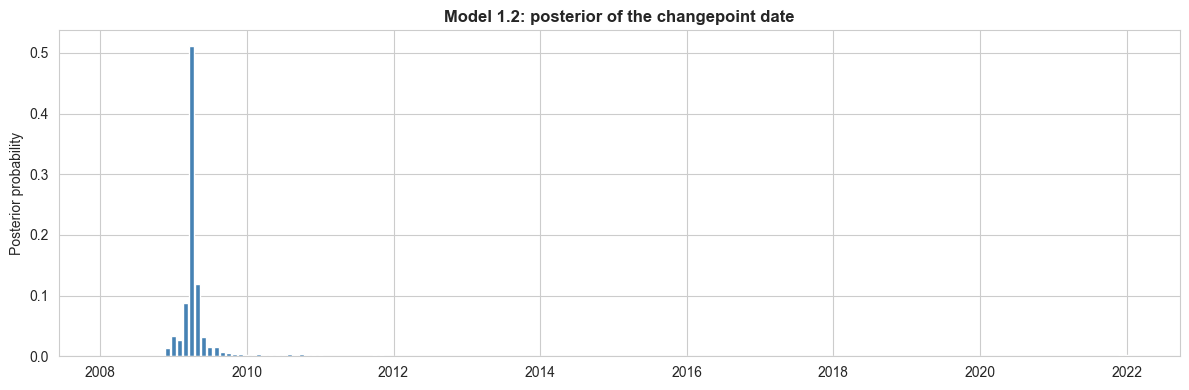

In [8]:
print("\nModel 1.2: One drift changepoint (marginalized)")
print("-" * 50)

candidate_s = np.arange(12, n - 12)                     # at least one year on each side
after = (np.arange(n)[None, :] >= candidate_s[:, None]).astype(float)   # (K, n)

with pm.Model() as model_1_2:
    mu_1 = pm.Normal("mu_1", mu=0, sigma=0.05)
    mu_2 = pm.Normal("mu_2", mu=0, sigma=0.05)
    sigma = pm.HalfNormal("sigma", sigma=0.1)

    mu_ks = mu_1 + (mu_2 - mu_1) * after                # (K, n): drift for each candidate s
    loglik_s = pm.logp(pm.Normal.dist(mu=mu_ks, sigma=sigma), r[None, :]).sum(axis=1)
    pm.Deterministic("loglik_s", loglik_s)
    pm.Potential("marginal_likelihood", pm.math.logsumexp(loglik_s) - np.log(len(candidate_s)))

    trace_1_2 = pm.sample(2000, tune=2000, chains=4, target_accept=0.95, random_seed=SEED)

check_convergence(trace_1_2, ["mu_1", "mu_2", "sigma"])

# Posterior of the changepoint date: average over draws of p(s | mu_1, mu_2, sigma, r)
ll = trace_1_2.posterior["loglik_s"].stack(sample=("chain", "draw")).values   # (K, S)
p_s = np.exp(ll - ll.max(axis=0, keepdims=True))
p_s = (p_s / p_s.sum(axis=0, keepdims=True)).mean(axis=1)

s_map = candidate_s[np.argmax(p_s)]
print(f"\nMost probable changepoint: {dates[s_map].date()} (posterior prob. {p_s.max():.3f})")
print(f"Posterior probability mass of the 12 most likely months: {np.sort(p_s)[-12:].sum():.3f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(dates[candidate_s], p_s, width=25, color="steelblue")
ax.set_title("Model 1.2: posterior of the changepoint date", fontsize=12, fontweight="bold")
ax.set_ylabel("Posterior probability")
plt.tight_layout()
plt.savefig("plots/model_1_2_changepoint.png", dpi=300, bbox_inches="tight")
plt.show()

If the posterior of the date is spread over many months, the data do not identify a single break in the drift. That is the expected outcome for noisy monthly returns, not a failure of the model.

## Model 1.2b: yearly drift changepoints with Laplace shrinkage

In [9]:
print("\nModel 1.2b: Yearly drift changepoints, constant sigma, Normal")
print("-" * 50)

with pm.Model() as model_1_2b:
    mu_t = drift(changepoint_matrix)
    sigma = pm.HalfNormal("sigma", sigma=0.1)
    obs = pm.Normal("obs", mu=mu_t, sigma=sigma, observed=r)

trace_1_2b = sample(model_1_2b)
summary_1_2b = check_convergence(trace_1_2b, ["mu0", "tau", "sigma", "adjustments"])

Initializing NUTS using jitter+adapt_diag...



Model 1.2b: Yearly drift changepoints, constant sigma, Normal
--------------------------------------------------


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu0, tau, z, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 13 seconds.


  max R-hat = 1.0043 | min ESS bulk = 1470 | min ESS tail = 2619 | divergences = 0 -> ✓ OK


### Prior predictive check

Simulated returns from the priors of model 1.2b should be plausible monthly returns (Gabry et al., 2019). We check their sd across simulated series.

In [10]:
with model_1_2b:
    prior_1_2b = pm.sample_prior_predictive(1000, random_seed=SEED)

sim = prior_1_2b.prior_predictive["obs"].stack(sample=("chain", "draw")).values   # (n, S)
sim_sd = sim.std(axis=0)
print(f"Observed sd of monthly returns: {r.std():.4f}")
print(f"Prior predictive sd: 5% {np.percentile(sim_sd, 5):.4f} | 50% {np.median(sim_sd):.4f} "
      f"| 95% {np.percentile(sim_sd, 95):.4f}")

Sampling: [mu0, obs, sigma, tau, z]


Observed sd of monthly returns: 0.0466
Prior predictive sd: 5% 0.0218 | 50% 0.0848 | 95% 0.2044


### Drift changes

A changepoint is called **credible** if the 94% HDI of its adjustment excludes 0. We also report $P(\delta_j > 0 \mid r)$. The original notebook called these changepoints "significant", which is frequentist terminology. With the Laplace prior no adjustment is exactly zero, so this is a descriptive summary and not a variable-selection procedure (Piironen & Vehtari, 2017).

In [11]:
def changepoint_table(trace):
    adj = trace.posterior["adjustments"].stack(sample=("chain", "draw")).values   # (J, S)
    hdi = az.hdi(trace, var_names=["adjustments"], hdi_prob=0.94)["adjustments"].values
    table = pd.DataFrame({
        "date": [d.strftime("%Y-%m") for d in changepoint_dates],
        "mean": adj.mean(axis=1),
        "hdi_3%": hdi[:, 0],
        "hdi_97%": hdi[:, 1],
        "P(delta>0)": (adj > 0).mean(axis=1),
    })
    table["credible"] = (table["hdi_3%"] > 0) | (table["hdi_97%"] < 0)
    return table

table_1_2b = changepoint_table(trace_1_2b)
print(table_1_2b.round(4).to_string(index=False))
print(f"\nCredible changepoints: {table_1_2b['credible'].sum()} of {n_changepoints}")

   date    mean  hdi_3%  hdi_97%  P(delta>0)  credible
2008-01 -0.0027 -0.0195   0.0098      0.3998     False
2009-01  0.0087 -0.0049   0.0326      0.8121     False
2010-01  0.0015 -0.0100   0.0144      0.6112     False
2011-01  0.0004 -0.0118   0.0116      0.5488     False
2012-01  0.0019 -0.0092   0.0148      0.6284     False
2013-01  0.0017 -0.0086   0.0154      0.6055     False
2014-01 -0.0012 -0.0138   0.0095      0.4545     False
2015-01 -0.0012 -0.0146   0.0094      0.4376     False
2016-01  0.0007 -0.0107   0.0127      0.5471     False
2017-01  0.0006 -0.0105   0.0120      0.5412     False
2018-01 -0.0012 -0.0145   0.0096      0.4430     False
2019-01  0.0023 -0.0090   0.0159      0.6174     False
2020-01 -0.0005 -0.0128   0.0104      0.4632     False
2021-01 -0.0010 -0.0139   0.0101      0.4328     False
2022-01 -0.0060 -0.0276   0.0060      0.2724     False

Credible changepoints: 0 of 15


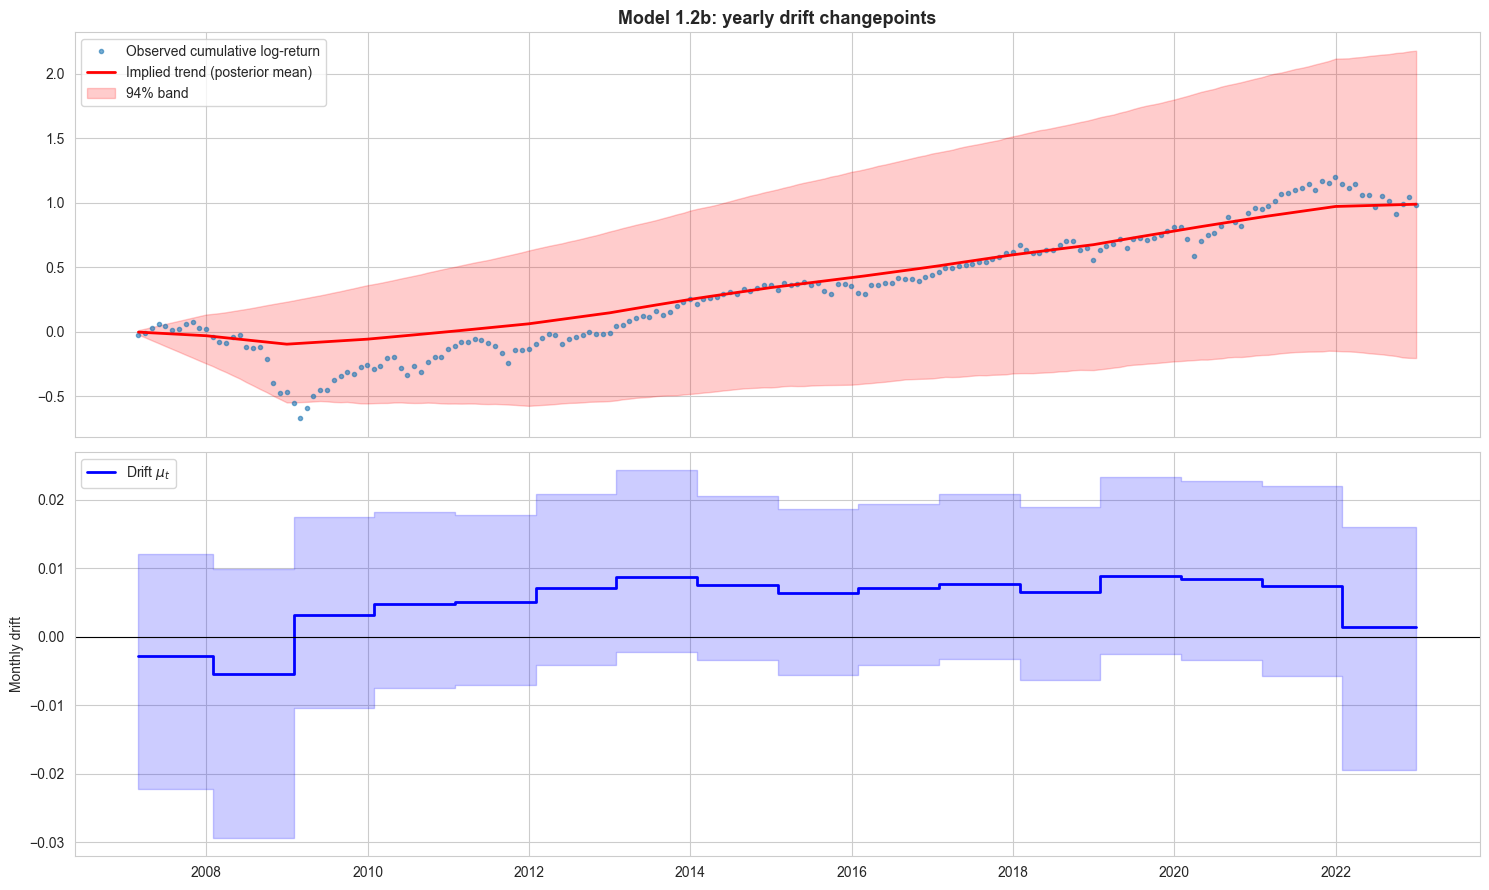

In [12]:
def plot_drift_fit(trace, title, filename):
    # Implied log-price trend = cumulative sum of the drift, compared with the observed log-price.
    # Plotted from posterior DRAWS (mean and 94% band), not from plug-in posterior means.
    mu_t = trace.posterior["mu_t"].stack(sample=("chain", "draw")).values        # (n, S)
    log_price = np.cumsum(r)
    trend = np.cumsum(mu_t, axis=0)
    band = np.percentile(trend, [3, 97], axis=1)

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
    axes[0].plot(dates, log_price, "o", ms=3, alpha=0.6, label="Observed cumulative log-return")
    axes[0].plot(dates, trend.mean(axis=1), "r-", lw=2, label="Implied trend (posterior mean)")
    axes[0].fill_between(dates, band[0], band[1], color="red", alpha=0.2, label="94% band")
    axes[0].set_title(title, fontsize=13, fontweight="bold")
    axes[0].legend(loc="upper left")

    drift_band = np.percentile(mu_t, [3, 97], axis=1)
    axes[1].plot(dates, mu_t.mean(axis=1), "b-", lw=2, drawstyle="steps-post", label="Drift $\\mu_t$")
    axes[1].fill_between(dates, drift_band[0], drift_band[1], color="blue", alpha=0.2, step="post")
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_ylabel("Monthly drift")
    axes[1].legend(loc="upper left")

    plt.tight_layout()
    plt.savefig(f"plots/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

plot_drift_fit(trace_1_2b, "Model 1.2b: yearly drift changepoints", "model_1_2b_full_analysis.png")

The band of the implied trend is wide. The cumulative sum of noisy returns is a random walk, and the model now acknowledges that uncertainty instead of hiding it.

*(The original model 1.2c, with changepoint dates as continuous parameters, is removed: see `CORRECTIONS.md`.)*

## Model 1.2d: constant volatility, Student-t errors

In [13]:
print("\nModel 1.2d: Yearly drift changepoints, constant sigma, Student-t")
print("-" * 50)

with pm.Model() as model_1_2d:
    mu_t = drift(changepoint_matrix)
    sigma = pm.HalfNormal("sigma", sigma=0.1)
    nu = pm.Gamma("nu", alpha=2, beta=0.1)
    obs = pm.StudentT("obs", mu=mu_t, sigma=sigma, nu=nu, observed=r)

trace_1_2d = sample(model_1_2d)
check_convergence(trace_1_2d, ["mu0", "tau", "sigma", "nu", "adjustments"])
print(az.summary(trace_1_2d, var_names=["sigma", "nu"])[["mean", "sd", "hdi_3%", "hdi_97%"]])

Initializing NUTS using jitter+adapt_diag...



Model 1.2d: Yearly drift changepoints, constant sigma, Student-t
--------------------------------------------------


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu0, tau, z, sigma, nu]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 20 seconds.


  max R-hat = 1.0015 | min ESS bulk = 1569 | min ESS tail = 3282 | divergences = 0 -> ✓ OK
        mean     sd  hdi_3%  hdi_97%
sigma   0.04  0.004   0.033    0.047
nu     11.11  8.097   2.184   25.362


## Model 1.3: segmented (yearly) volatility, Normal errors

One volatility per calendar year, $\log \sigma_j = m + s\, z_j$, with $z_j \sim N(0,1)$. In the original code the hyper-parameters `sigma_mean` and `sigma_std` were declared but **never used**: the $\sigma_j$ were independent HalfNormal(1) variables, and the hyper-parameters just reproduced their priors. Here the partial pooling is real, and it is also what makes a forecast for a *new* year possible (below).

In [14]:
print("\nModel 1.3: Yearly drift changepoints, yearly sigma (hierarchical), Normal")
print("-" * 50)

with pm.Model() as model_1_3:
    mu_t = drift(changepoint_matrix)
    sigmas = hierarchical_sigmas(n_years)
    obs = pm.Normal("obs", mu=mu_t, sigma=sigmas[year_idx], observed=r)

trace_1_3 = sample(model_1_3)
check_convergence(trace_1_3, ["mu0", "tau", "log_sigma_mean", "log_sigma_sd", "sigmas", "adjustments"])

Initializing NUTS using jitter+adapt_diag...



Model 1.3: Yearly drift changepoints, yearly sigma (hierarchical), Normal
--------------------------------------------------


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu0, tau, z, log_sigma_mean, log_sigma_sd, z_sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 21 seconds.


  max R-hat = 1.0019 | min ESS bulk = 2399 | min ESS tail = 3658 | divergences = 0 -> ✓ OK


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu0,0.004514,0.007001,-0.008874,0.016563,0.000114,0.000093,3895.661602,4604.513567,1.000236
tau,0.003009,0.002653,0.000002,0.007741,0.000051,0.000053,2399.455023,4160.668994,1.001008
log_sigma_mean,-3.224259,0.128323,-3.463214,-2.978193,0.002470,0.001831,2707.716010,3658.380558,1.000853
log_sigma_sd,0.469729,0.108197,0.286930,0.679050,0.002098,0.001405,2628.622486,4387.473595,1.001286
sigmas[0],0.032583,0.007370,0.021067,0.046858,0.000084,0.000118,9739.040727,5041.114373,1.001455
sigmas[1],0.071941,0.013907,0.047669,0.097484,0.000145,0.000167,9371.633028,6671.276200,1.000305
sigmas[2],0.061525,0.011708,0.041632,0.083341,0.000115,0.000155,11756.918077,7008.910188,0.999971
sigmas[3],0.053458,0.010358,0.035821,0.072594,0.000102,0.000148,12033.440998,6448.791163,1.000473
sigmas[4],0.045978,0.009248,0.029996,0.062454,0.000097,0.000167,12034.582796,5730.500819,0.999937
sigmas[5],0.032922,0.006840,0.021882,0.045834,0.000072,0.000104,11266.720748,5653.382382,1.000898


Yearly volatility (monthly sd), posterior mean and 94% interval:
  2007: 0.0326  [0.0221, 0.0492]
  2008: 0.0719  [0.0508, 0.1026]
  2009: 0.0615  [0.0440, 0.0878]
  2010: 0.0535  [0.0380, 0.0762]
  2011: 0.0460  [0.0327, 0.0676]
  2012: 0.0329  [0.0229, 0.0477]
  2013: 0.0295  [0.0201, 0.0444]
  2014: 0.0268  [0.0180, 0.0402]
  2015: 0.0412  [0.0287, 0.0603]
  2016: 0.0319  [0.0219, 0.0468]
  2017: 0.0161  [0.0096, 0.0266]
  2018: 0.0473  [0.0337, 0.0669]
  2019: 0.0393  [0.0271, 0.0567]
  2020: 0.0685  [0.0495, 0.0970]
  2021: 0.0348  [0.0240, 0.0507]
  2022: 0.0670  [0.0476, 0.0954]


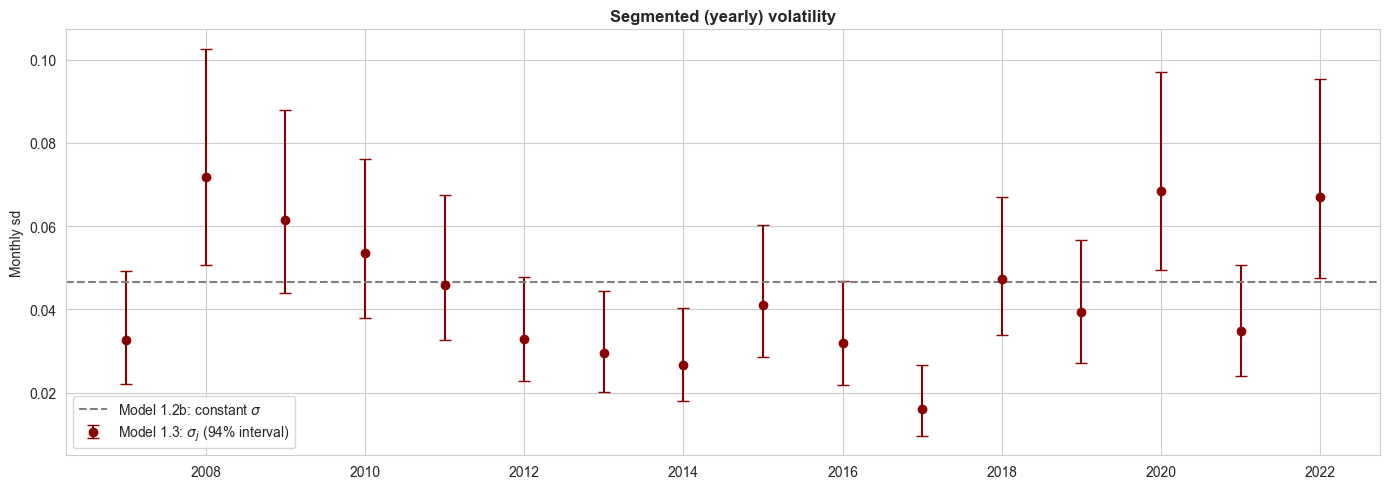

In [15]:
sig = trace_1_3.posterior["sigmas"].stack(sample=("chain", "draw")).values     # (years, S)
years = np.arange(dates.year.min(), dates.year.max() + 1)
sig_hdi = np.percentile(sig, [3, 97], axis=1)

print("Yearly volatility (monthly sd), posterior mean and 94% interval:")
for j, y in enumerate(years):
    print(f"  {y}: {sig[j].mean():.4f}  [{sig_hdi[0, j]:.4f}, {sig_hdi[1, j]:.4f}]")

fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(years, sig.mean(axis=1), yerr=[sig.mean(axis=1) - sig_hdi[0], sig_hdi[1] - sig.mean(axis=1)],
            fmt="o", capsize=4, color="darkred", label="Model 1.3: $\\sigma_j$ (94% interval)")
ax.axhline(trace_1_2b.posterior["sigma"].mean(), color="gray", ls="--", label="Model 1.2b: constant $\\sigma$")
ax.set_title("Segmented (yearly) volatility", fontsize=12, fontweight="bold")
ax.set_ylabel("Monthly sd")
ax.legend()
plt.tight_layout()
plt.savefig("plots/model_1_3_segmented_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

## Model 1.3t: segmented volatility, Student-t errors

In [16]:
print("\nModel 1.3t: Yearly drift changepoints, yearly sigma (hierarchical), Student-t")
print("-" * 50)

with pm.Model() as model_1_3t:
    mu_t = drift(changepoint_matrix)
    sigmas = hierarchical_sigmas(n_years)
    nu = pm.Gamma("nu", alpha=2, beta=0.1)
    obs = pm.StudentT("obs", mu=mu_t, sigma=sigmas[year_idx], nu=nu, observed=r)

trace_1_3t = sample(model_1_3t)
check_convergence(trace_1_3t, ["mu0", "tau", "log_sigma_mean", "log_sigma_sd", "nu", "sigmas", "adjustments"])

Initializing NUTS using jitter+adapt_diag...



Model 1.3t: Yearly drift changepoints, yearly sigma (hierarchical), Student-t
--------------------------------------------------


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu0, tau, z, log_sigma_mean, log_sigma_sd, z_sigma, nu]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 27 seconds.


  max R-hat = 1.0018 | min ESS bulk = 2105 | min ESS tail = 3418 | divergences = 0 -> ✓ OK


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu0,0.005072,0.007122,-8.508938e-03,0.017041,0.000113,0.000097,4131.368485,4571.878118,1.001272
tau,0.003094,0.002752,4.734488e-08,0.007942,0.000056,0.000057,2104.914789,3418.342691,1.001309
log_sigma_mean,-3.273575,0.134048,-3.526481e+00,-3.022484,0.002481,0.001847,2928.489180,4132.135070,1.000899
log_sigma_sd,0.471533,0.110684,2.836132e-01,0.685822,0.002140,0.001420,2692.064805,4068.515369,1.000328
nu,22.877833,13.800290,3.814895e+00,47.605327,0.154735,0.206256,8128.151193,5998.742392,1.000451
sigmas[0],0.031512,0.007191,1.976368e-02,0.045140,0.000076,0.000103,10374.245601,6011.435876,1.000609
sigmas[1],0.065512,0.014046,3.965495e-02,0.091123,0.000156,0.000185,8101.485228,6247.414178,1.000372
sigmas[2],0.058113,0.011714,3.796886e-02,0.080571,0.000109,0.000166,11475.689593,5762.683378,1.001138
sigmas[3],0.051667,0.010511,3.403061e-02,0.071486,0.000106,0.000144,11282.348676,6468.555470,1.000304
sigmas[4],0.042779,0.008859,2.725837e-02,0.059201,0.000087,0.000129,11026.346158,5851.860940,1.000128


## Model comparison (PSIS-LOO)

We use PSIS-LOO instead of WAIC. In the original notebook WAIC raised a warning in every comparison, and PSIS-LOO comes with its own reliability diagnostic, the Pareto $\hat k$ (Vehtari, Gelman & Gabry, 2017). A difference is read **relative to its standard error** `dse`: $|\Delta\text{elpd}| < 2\,\text{dse}$ means the models cannot be distinguished. Fixed thresholds such as "Δ > 4 = strong" ignore the uncertainty. The stacking `weight` is not a probability that a model is true (Yao et al., 2018).

*Caveat.* LOO conditions on future months when predicting a past one. The out-of-sample test below is the time-ordered check.

In [17]:
traces = {"1.2b: const sigma, Normal": trace_1_2b,
          "1.2d: const sigma, Student-t": trace_1_2d,
          "1.3: yearly sigma, Normal": trace_1_3,
          "1.3t: yearly sigma, Student-t": trace_1_3t}

for name, tr in traces.items():
    loo = az.loo(tr, pointwise=True)
    print(f"{name:32s} elpd_loo = {loo.elpd_loo:7.2f} (se {loo.se:5.2f}) | "
          f"Pareto k > 0.7: {int((loo.pareto_k.values > 0.7).sum())}")

comparison = az.compare(traces, ic="loo")
comparison["diff / dse"] = comparison["elpd_diff"] / comparison["dse"]
print()
print(comparison[["elpd_loo", "p_loo", "elpd_diff", "dse", "diff / dse", "weight"]].round(2).to_string())

1.2b: const sigma, Normal        elpd_loo =  311.86 (se 12.60) | Pareto k > 0.7: 0
1.2d: const sigma, Student-t     elpd_loo =  314.62 (se 12.48) | Pareto k > 0.7: 0


/Users/macbookpro/Desktop/bayesian-volatility-regimes/bayesvol/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


1.3: yearly sigma, Normal        elpd_loo =  334.06 (se 12.26) | Pareto k > 0.7: 1
1.3t: yearly sigma, Student-t    elpd_loo =  333.95 (se 12.31) | Pareto k > 0.7: 0


/Users/macbookpro/Desktop/bayesian-volatility-regimes/bayesvol/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



                               elpd_loo  p_loo  elpd_diff   dse  diff / dse  weight
1.3: yearly sigma, Normal        334.06  16.51       0.00  0.00         NaN    0.69
1.3t: yearly sigma, Student-t    333.95  15.89       0.11  0.77        0.14    0.30
1.2d: const sigma, Student-t     314.62   7.74      19.44  5.57        3.49    0.00
1.2b: const sigma, Normal        311.86   6.89      22.20  6.63        3.35    0.01


## Degrees of freedom: prior vs posterior

$\nu$ is compared with its prior. If the posterior is not much more concentrated than Gamma(2, 0.1), the data say little about the tails, and conclusions such as "nearly Normal" are not supported.

Model 1.2d (constant sigma): nu mean 11.1, 94% interval [3.4, 31.6]
Model 1.3t (yearly sigma): nu mean 22.9, 94% interval [6.4, 55.7]


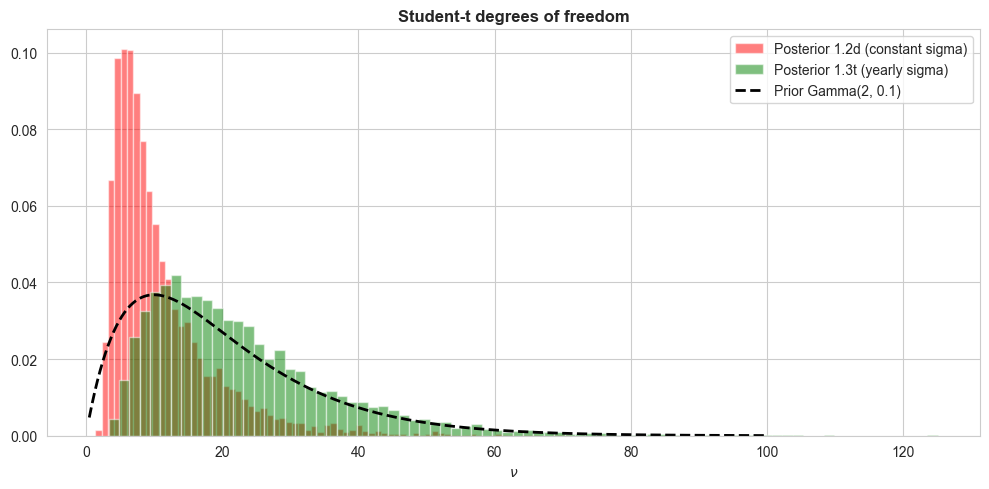

In [18]:
grid = np.linspace(0.5, 100, 500)
fig, ax = plt.subplots(figsize=(10, 5))
for name, tr, color in [("1.2d (constant sigma)", trace_1_2d, "red"),
                        ("1.3t (yearly sigma)", trace_1_3t, "green")]:
    nu_s = tr.posterior["nu"].values.flatten()
    lo, hi = np.percentile(nu_s, [3, 97])
    print(f"Model {name}: nu mean {nu_s.mean():.1f}, 94% interval [{lo:.1f}, {hi:.1f}]")
    ax.hist(nu_s, bins=80, density=True, alpha=0.5, color=color, label=f"Posterior {name}")
ax.plot(grid, stats.gamma.pdf(grid, a=2, scale=10), "k--", lw=2, label="Prior Gamma(2, 0.1)")
ax.set_xlabel(r"$\nu$")
ax.set_title("Student-t degrees of freedom", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plots/phase1_key_findings.png", dpi=300, bbox_inches="tight")
plt.show()

## Posterior predictive checks

The original notebook checked residuals computed from **posterior means** (plug-in). Here we replicate whole return series from the posterior predictive distribution and compare two stylized facts (Cont, 2001) with the observed values (Gelman et al., 2013, Ch. 6):

* **excess kurtosis** of $r_t$ (heavy tails);
* **ACF(1) of $|r_t|$** (volatility clustering).

p-values close to 0 or 1 indicate that the model does not reproduce the feature.

Sampling: [obs]
Sampling: [obs]
Sampling: [obs]
Sampling: [obs]


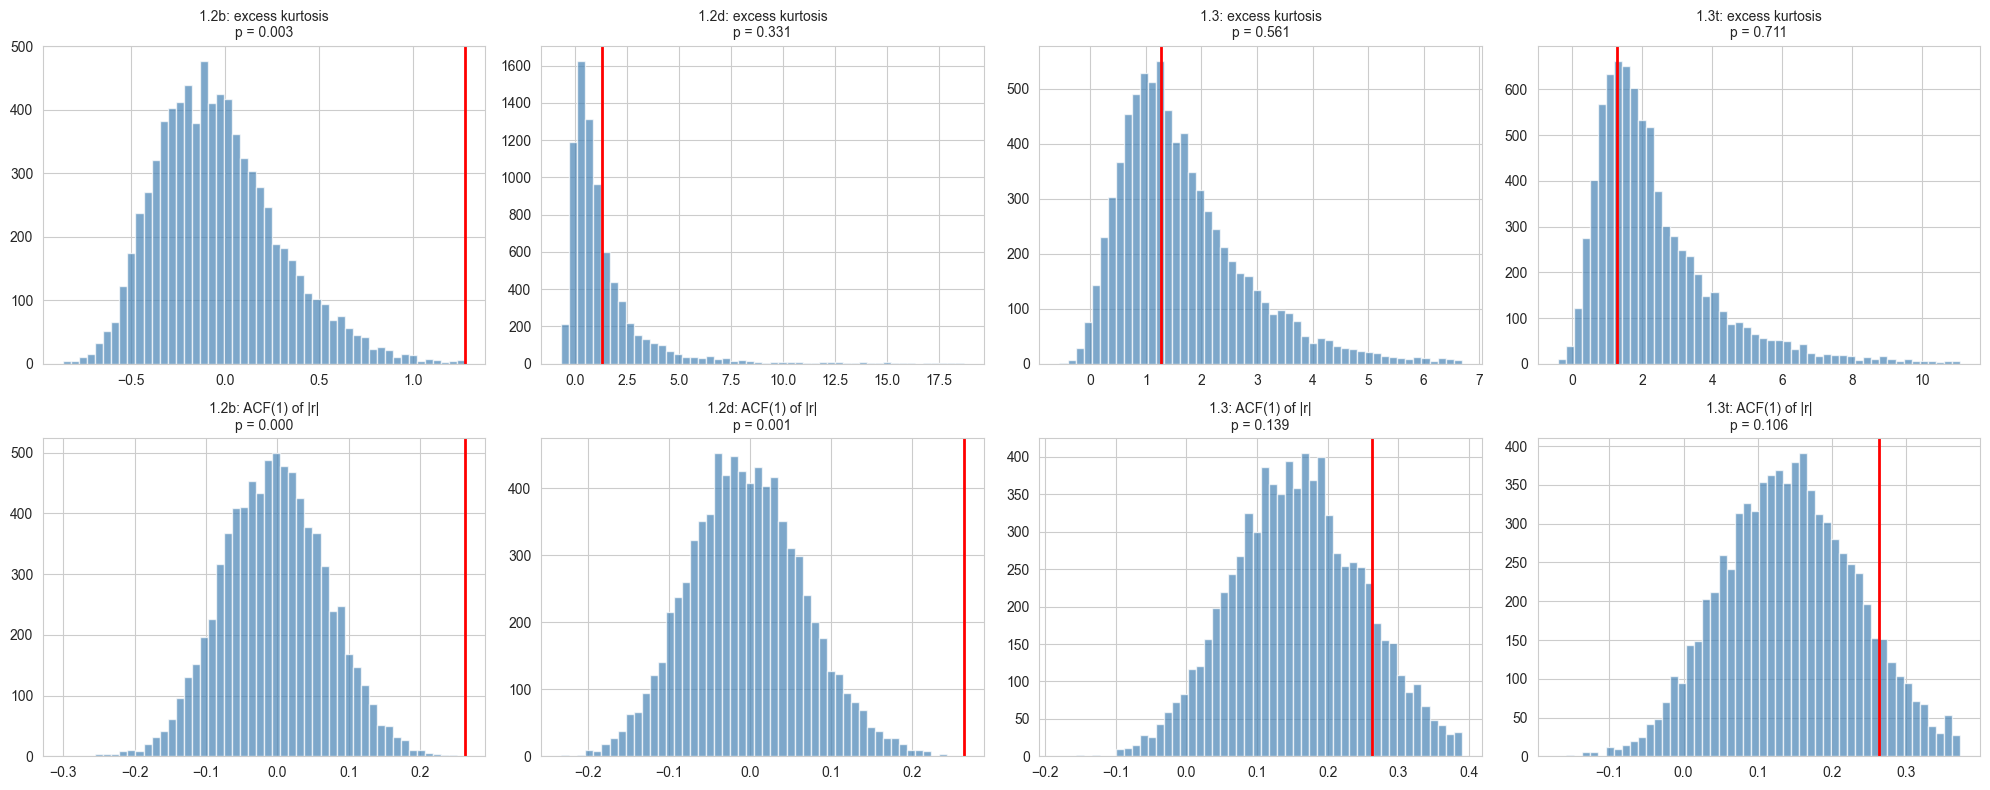

      ACF(1) of |r|  excess kurtosis
1.2b          0.000            0.003
1.2d          0.000            0.331
1.3           0.139            0.562
1.3t          0.106            0.711


In [19]:
def ppc_stats(x):
    a = np.abs(x) - np.abs(x).mean(axis=-1, keepdims=True)
    return {"excess kurtosis": stats.kurtosis(x, axis=-1),
            "ACF(1) of |r|": (a[..., 1:] * a[..., :-1]).mean(axis=-1) / (a**2).mean(axis=-1)}

obs_stats = {k: float(v) for k, v in ppc_stats(r).items()}
models = {"1.2b": (model_1_2b, trace_1_2b), "1.2d": (model_1_2d, trace_1_2d),
          "1.3": (model_1_3, trace_1_3), "1.3t": (model_1_3t, trace_1_3t)}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
ppc_table = {}
for col, (name, (model, tr)) in enumerate(models.items()):
    with model:
        ppc = pm.sample_posterior_predictive(tr, random_seed=SEED, progressbar=False)
    rep = ppc.posterior_predictive["obs"].stack(sample=("chain", "draw")).transpose("sample", ...).values
    rep_stats = ppc_stats(rep)
    for row, key in enumerate(rep_stats):
        p = np.mean(rep_stats[key] >= obs_stats[key])
        ppc_table[(name, key)] = p
        upper = max(np.percentile(rep_stats[key], 99), obs_stats[key])
        axes[row, col].hist(rep_stats[key], bins=50, range=(rep_stats[key].min(), upper),
                            color="steelblue", alpha=0.7)
        axes[row, col].axvline(obs_stats[key], color="red", lw=2)
        axes[row, col].set_title(f"{name}: {key}\np = {p:.3f}", fontsize=10)

plt.tight_layout()
plt.savefig("plots/phase1_posterior_predictive_checks.png", dpi=300, bbox_inches="tight")
plt.show()

print(pd.Series(ppc_table).unstack().round(3).to_string())

## Out-of-sample forecast (2023-2025)

We forecast the 36 monthly returns of the test period with the **posterior predictive distribution** of each model, using only 2007-2022 data. Each new calendar year is a new segment, exactly as in the model's generative story:

* drift: a new changepoint every January, $\delta_{new} = \tau z$, $z \sim \text{Laplace}(0,1)$;
* volatility (models 1.3/1.3t): $\log \sigma_{new} \sim N(m, s)$ from the hierarchical population. This is a proper Bayesian forecast for a year never seen before.

The original forecast used an ad-hoc EWMA update of the posterior samples ($\alpha$ = 0.15, not part of any model). It also mixed the dispersion of the log-price around the trend with the volatility of the returns.

**Scoring.**
* **Log predictive density** of each test month, a proper scoring rule (Gneiting & Raftery, 2007). Higher is better.
* **Empirical coverage** of the central 90% predictive interval, which should be ≈ 90%.
* **Benchmark:** model 1.1 (constant drift and volatility).

In [20]:
test_r = returns_test.values
test_year = (returns_test.index.year - returns_test.index.year.min()).values
n_test, n_new_years = len(test_r), int(test_year.max() + 1)


def predictive_draws(trace, segmented, student_t, n_draws=4000):
    # Returns location, scale, nu for each (draw, test month)
    post = trace.posterior.stack(sample=("chain", "draw"))
    idx = rng.choice(post.sizes["sample"], n_draws, replace=False)

    if "mu_t" in post:      # drift models: last drift + a new Laplace change each new year
        mu_last = post["mu_t"].values[-1, idx]
        tau = post["tau"].values[idx]
        new_changes = tau[:, None] * rng.laplace(0, 1, size=(n_draws, n_new_years))
        mu_years = mu_last[:, None] + np.cumsum(new_changes, axis=1)
    else:                   # model 1.1: constant drift
        mu_years = np.repeat(post["mu"].values[idx][:, None], n_new_years, axis=1)

    if segmented:           # new yearly volatilities from the hierarchical population
        m = post["log_sigma_mean"].values[idx]
        s = post["log_sigma_sd"].values[idx]
        sigma_years = np.exp(m[:, None] + s[:, None] * rng.standard_normal((n_draws, n_new_years)))
    else:
        sigma_years = np.repeat(post["sigma"].values[idx][:, None], n_new_years, axis=1)

    nu = post["nu"].values[idx] if student_t else None
    return mu_years[:, test_year], sigma_years[:, test_year], nu


def score(loc, scale, nu):
    if nu is None:
        dens = stats.norm.pdf(test_r[None, :], loc, scale)
    else:
        dens = stats.t.pdf(test_r[None, :], nu[:, None], loc, scale)
    lpd = np.log(dens.mean(axis=0))                 # pointwise log predictive density

    # 90% predictive interval from simulated returns
    eps = rng.standard_normal(loc.shape) if nu is None else rng.standard_t(nu[:, None], size=loc.shape)
    sims = loc + scale * eps
    lo, hi = np.percentile(sims, [5, 95], axis=0)
    coverage = np.mean((test_r >= lo) & (test_r <= hi))
    return lpd, coverage, lo, hi


forecasts = {
    "1.1: constant (benchmark)": predictive_draws(trace_1_1, False, False),
    "1.2b: const sigma, Normal": predictive_draws(trace_1_2b, False, False),
    "1.2d: const sigma, Student-t": predictive_draws(trace_1_2d, False, True),
    "1.3: yearly sigma, Normal": predictive_draws(trace_1_3, True, False),
    "1.3t: yearly sigma, Student-t": predictive_draws(trace_1_3t, True, True),
}

results, intervals = {}, {}
for name, (loc, scale, nu) in forecasts.items():
    lpd, cov, lo, hi = score(loc, scale, nu)
    results[name] = {"sum log pred. density": lpd.sum(), "90% coverage": cov}
    intervals[name] = (lo, hi)

results = pd.DataFrame(results).T
print(results.round(3).to_string())

                               sum log pred. density  90% coverage
1.1: constant (benchmark)                     66.821         0.972
1.2b: const sigma, Normal                     65.410         0.972
1.2d: const sigma, Student-t                  66.312         0.972
1.3: yearly sigma, Normal                     67.352         1.000
1.3t: yearly sigma, Student-t                 67.254         1.000


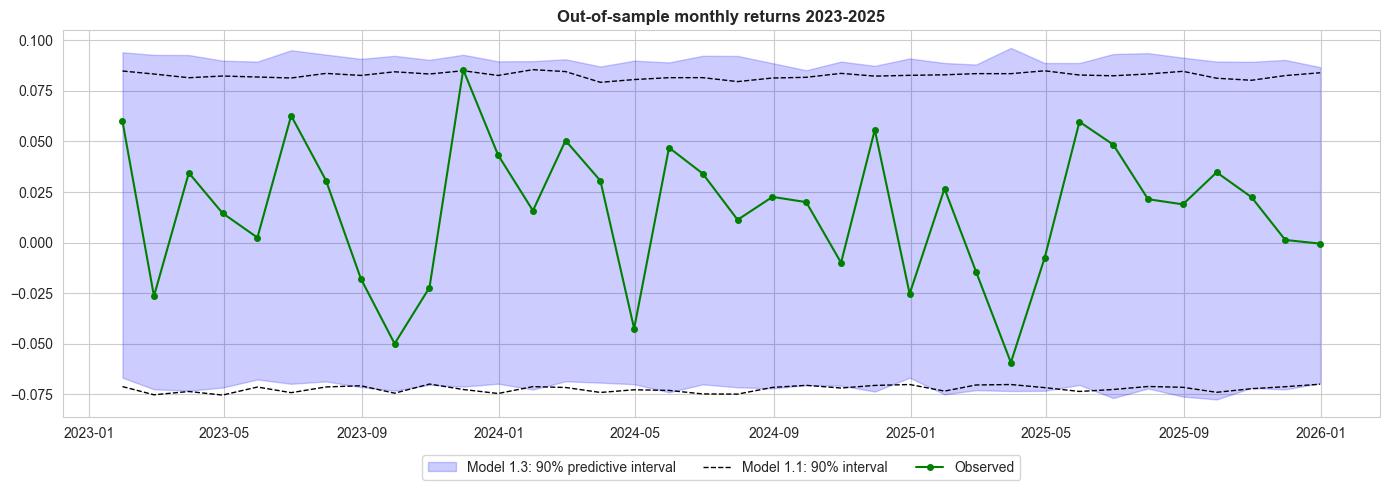

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
lo, hi = intervals["1.3: yearly sigma, Normal"]
ax.fill_between(returns_test.index, lo, hi, color="blue", alpha=0.2, label="Model 1.3: 90% predictive interval")
lo, hi = intervals["1.1: constant (benchmark)"]
ax.plot(returns_test.index, lo, "k--", lw=1, label="Model 1.1: 90% interval")
ax.plot(returns_test.index, hi, "k--", lw=1)
ax.plot(returns_test.index, test_r, "go-", ms=4, label="Observed")
ax.set_title("Out-of-sample monthly returns 2023-2025", fontsize=12, fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.tight_layout()
plt.savefig("plots/phase1_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary of Phase 1 (to be filled with the numbers above)

Report, with their uncertainty:
1. the LOO differences relative to `dse`;
2. the posterior of $\nu$ vs its prior for 1.2d and 1.3t;
3. which stylized facts each model reproduces (posterior predictive p-values);
4. the out-of-sample log score and coverage compared with the benchmark 1.1.

Monthly data are a weak test of the "fat tails vs volatility clustering" question, because temporal aggregation reduces kurtosis. Phase 2 uses weekly and daily data.